# polynomial regression with different degrees

In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(r"/home/chunjielu/25sum/ML/dataset/Advertising.csv")
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [101]:
X = df.drop('sales',axis=1)
y = df['sales']

In [102]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

# TRAINING ERROR PER DEGREE
train_rmse_errors = []

# TEST ERROR PER DEGREE
test_rmse_errors = []


train_mae_errors = []
test_mae_errors = []


# Iterating through different polynomial degrees
for d in range(1, 10):
    
    # CREATE POLY DATA SET FOR DEGREE "d"
    # Initialize the PolynomialFeatures converter to create polynomial features of degree 'd' from the original features.
    polynomial_converter = PolynomialFeatures(degree=d, include_bias=False)
    poly_features = polynomial_converter.fit_transform(X)
    
    # SPLIT THIS NEW POLY DATA SET
    # Split the polynomial feature set into training and test sets.
    X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)
    
    # TRAIN ON THIS NEW POLY SET
    # Initialize a Linear Regression model and fit it to the training data.
    model = LinearRegression(fit_intercept=True)
    model.fit(X_train, y_train)
    
    # PREDICT ON BOTH TRAIN AND TEST
    # Make predictions using the trained model on both the training and test data.
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    # Calculate Errors
    
    # Errors on Train Set
    # Calculate the root mean squared error (RMSE) for the training predictions.
    train_RMSE = np.sqrt(mean_squared_error(y_train, train_pred))
    train_MAE = mean_absolute_error(y_train, train_pred)
    # Errors on Test Set
    # Calculate the RMSE for the test predictions.
    test_RMSE = np.sqrt(mean_squared_error(y_test, test_pred))
    test_MAE = mean_absolute_error(y_test, test_pred)
    # Append errors to lists for plotting later
    # Store the calculated RMSE values in lists for both the training and test sets.
    train_rmse_errors.append(train_RMSE)
    test_rmse_errors.append(test_RMSE)

    train_mae_errors.append(train_MAE)
    test_mae_errors.append(test_MAE)


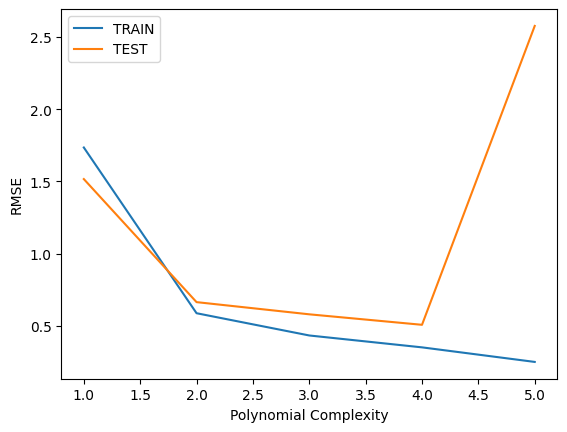

In [103]:
plt.plot(range(1,6),train_rmse_errors[:5],label='TRAIN')
plt.plot(range(1,6),test_rmse_errors[:5],label='TEST')
plt.xlabel("Polynomial Complexity")
plt.ylabel("RMSE")
plt.legend()

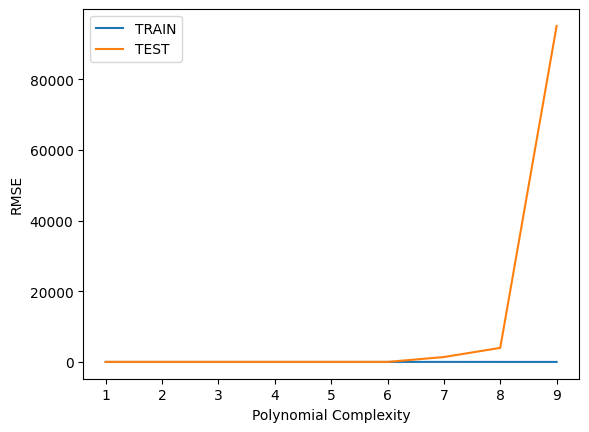

In [104]:
plt.plot(range(1,10),train_rmse_errors,label='TRAIN')
plt.plot(range(1,10),test_rmse_errors,label='TEST')
plt.xlabel("Polynomial Complexity")
plt.ylabel("RMSE")
plt.legend()

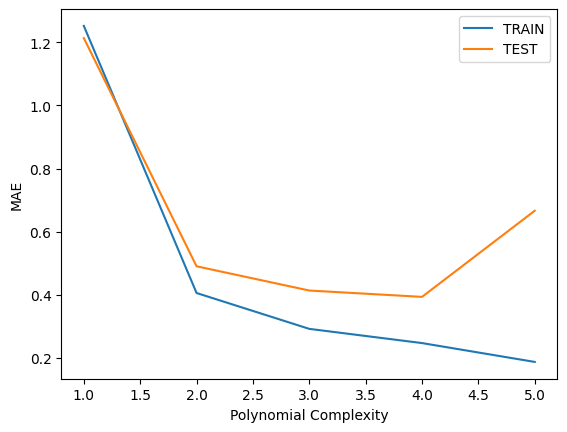

In [105]:
plt.plot(range(1,6),train_mae_errors[:5],label='TRAIN')
plt.plot(range(1,6),test_mae_errors[:5],label='TEST')
plt.xlabel("Polynomial Complexity")
plt.ylabel("MAE")
plt.legend()

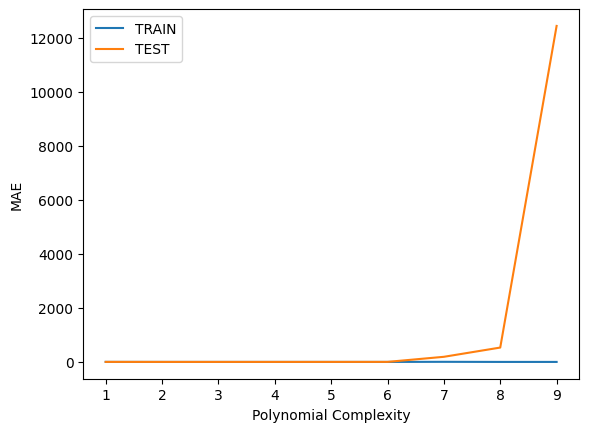

In [106]:
plt.plot(range(1,10),train_mae_errors,label='TRAIN')
plt.plot(range(1,10),test_mae_errors,label='TEST')
plt.xlabel("Polynomial Complexity")
plt.ylabel("MAE")
plt.legend()

In [107]:
"""
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge

polynomial_converter = PolynomialFeatures(degree=2,include_bias=False)
poly_features = polynomial_converter.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train, y_train)
test_predictions = ridge_model.predict(X_test)
train_predictions = ridge_model.predict(X_train)

train_RMSE = np.sqrt(mean_squared_error(y_train,train_predictions))
train_MAE = mean_absolute_error(y_train, train_predictions)

test_RMSE = np.sqrt(mean_squared_error(y_test, test_predictions))
test_MAE = mean_absolute_error(y_test, test_predictions)
print(f'Test error after feature scaling: \n RMSE: {test_RMSE} \n MAE: {test_MAE}')
#print(train_RMSE, train_MAE)

polynomial_converter = PolynomialFeatures(degree=2,include_bias=False)
poly_features = polynomial_converter.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)


ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train, y_train)
test_predictions = ridge_model.predict(X_test)
train_predictions = ridge_model.predict(X_train)

train_RMSE = np.sqrt(mean_squared_error(y_train,train_predictions))
train_MAE = mean_absolute_error(y_train, train_predictions)

test_RMSE = np.sqrt(mean_squared_error(y_test, test_predictions))
test_MAE = mean_absolute_error(y_test, test_predictions)
print(f'Test error without feature scaling: \n RMSE: {test_RMSE} \n MAE: {test_MAE}')
#print(train_RMSE, train_MAE)

"""


"\nfrom sklearn.preprocessing import PolynomialFeatures\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.linear_model import Ridge\n\npolynomial_converter = PolynomialFeatures(degree=2,include_bias=False)\npoly_features = polynomial_converter.fit_transform(X)\nX_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)\nscaler = StandardScaler()\nscaler.fit(X_train)\nX_train = scaler.transform(X_train)\nX_test = scaler.transform(X_test)\n\nridge_model = Ridge(alpha=0.1)\nridge_model.fit(X_train, y_train)\ntest_predictions = ridge_model.predict(X_test)\ntrain_predictions = ridge_model.predict(X_train)\n\ntrain_RMSE = np.sqrt(mean_squared_error(y_train,train_predictions))\ntrain_MAE = mean_absolute_error(y_train, train_predictions)\n\ntest_RMSE = np.sqrt(mean_squared_error(y_test, test_predictions))\ntest_MAE = mean_absolute_error(y_test, test_predictions)\nprint(f'Test error a

# regularization

In [108]:

from sklearn.preprocessing import StandardScaler
df = pd.read_csv("/home/chunjielu/25sum/ML/dataset/Advertising.csv")
X = df.drop('sales',axis=1)
y = df['sales']
polynomial_converter = PolynomialFeatures(degree=8,include_bias=False)
poly_features = polynomial_converter.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)
# feature scaling
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [109]:
model = LinearRegression(fit_intercept=True)
model.fit(X_train,y_train)
print('without regularization')
test_predictions = model.predict(X_test)
MAE = mean_absolute_error(y_test,test_predictions)
MSE = mean_squared_error(y_test,test_predictions)
RMSE = np.sqrt(MSE)
print('loss: ',MAE,RMSE)

without regularization
loss:  196.80490914010258 1396.8451788750585


In [110]:
from sklearn.linear_model import RidgeCV
ridge_cv_model = RidgeCV(alphas=(0.1, 1.0, 10.0), scoring='neg_mean_absolute_error')
ridge_cv_model.fit(X_train,y_train)
print('L2 regularization')
print(f'parameter chosen: {ridge_cv_model.alpha_}')
test_predictions = ridge_cv_model.predict(X_test)
MAE = mean_absolute_error(y_test,test_predictions)
MSE = mean_squared_error(y_test,test_predictions)
RMSE = np.sqrt(MSE)
print('loss: ',MAE,RMSE)

L2 regularization
parameter chosen: 1.0
loss:  0.5654405325750499 0.8184359440633847


In [111]:
from sklearn.linear_model import LassoCV
lasso_cv_model = LassoCV(eps=0.1, n_alphas=100, cv=5)
lasso_cv_model.fit(X_train,y_train)
print('L1 regularization')
print(f'parameter chosen: {lasso_cv_model.alpha_}')
test_predictions = lasso_cv_model.predict(X_test)
MAE = mean_absolute_error(y_test,test_predictions)
MSE = mean_squared_error(y_test,test_predictions)
RMSE = np.sqrt(MSE)
print('loss: ',MAE,RMSE)

L1 regularization
parameter chosen: 0.4943070909225831
loss:  0.654172316849586 1.1308000958086062


In [112]:
from sklearn.linear_model import ElasticNetCV
elastic_model = ElasticNetCV(l1_ratio=[.1, .5, .7,.9, .95, .99, 1],tol=0.01)
elastic_model.fit(X_train,y_train)
print('L1 and L2 regularization')
print(f'parameter chosen:{elastic_model.l1_ratio_}')
test_predictions = elastic_model.predict(X_test)
MAE = mean_absolute_error(y_test,test_predictions)
MSE = mean_squared_error(y_test,test_predictions)
RMSE = np.sqrt(MSE)
print('loss: ',MAE,RMSE)

L1 and L2 regularization
parameter chosen:1.0
loss:  0.5426872669329328 0.7685200916896915


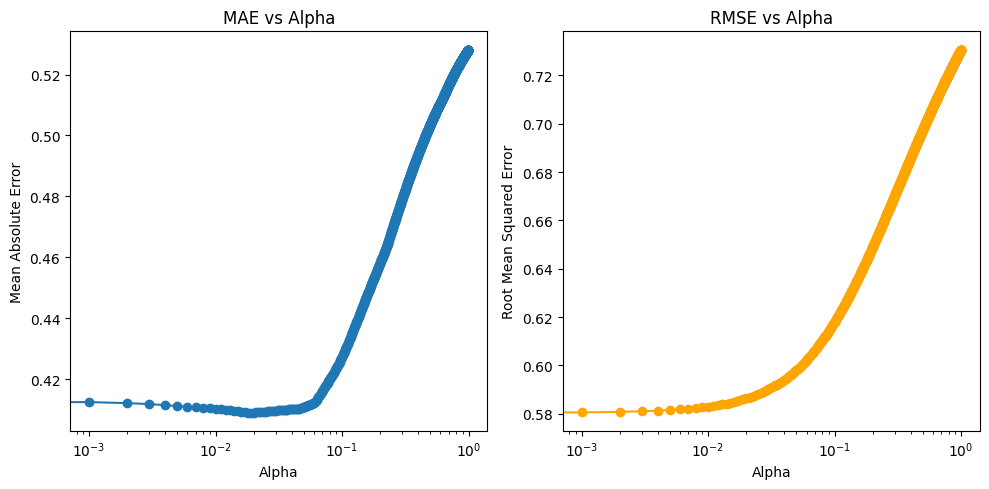

In [113]:
from sklearn.preprocessing import StandardScaler
df = pd.read_csv("/home/chunjielu/25sum/ML/dataset/Advertising.csv")
X = df.drop('sales',axis=1)
y = df['sales']
polynomial_converter = PolynomialFeatures(degree=3,include_bias=False)
poly_features = polynomial_converter.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)
# feature scaling
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

alphas = np.arange(0, 1, 0.001)
mae_list = []
rmse_list = []

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    
    mae_list.append(mae)
    rmse_list.append(rmse)


plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(alphas, mae_list, marker='o')
plt.title('MAE vs Alpha')
plt.xlabel('Alpha')
plt.ylabel('Mean Absolute Error')
plt.xscale('log')  
plt.subplot(1, 2, 2)
plt.plot(alphas, rmse_list, marker='o', color='orange')
plt.title('RMSE vs Alpha')
plt.xlabel('Alpha')
plt.ylabel('Root Mean Squared Error')
plt.xscale('log')

plt.tight_layout()
plt.show()
